# Hugging Face Open-Model Pulse

This notebook tracks real Hugging Face model metadata snapshots. A single snapshot is a cross-sectional table; repeated snapshots become a time series.

No synthetic fallback is used. If the Hub API is unavailable, the notebook stops.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prefer the checkout when this notebook is run inside the repository.
repo_root = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]:
    if (candidate / "src" / "detime").exists():
        repo_root = candidate
        break
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root))

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_language_guardrails

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = repo_root / "examples" / "hot_trends" / "cache"
OUTPUT_DIR = repo_root / "examples" / "hot_trends" / "outputs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    relative_path = path.relative_to(repo_root).as_posix()
    print(f"saved: {relative_path}")


## 1. Fetch a real model snapshot


In [2]:
snapshot = fetch_huggingface_models(limit=50, sort="downloads", direction=-1)
snapshot.head(20)


,snapshot_date,model_id,pipeline_tag,downloads,likes,last_modified,private,source,data_quality
0,2026-05-22,sentence-transformers/all-MiniLM-L6-v2,sentence-similarity,260087615,4819,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
1,2026-05-22,Qwen/Qwen3-VL-2B-Instruct,image-text-to-text,89788352,410,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
2,2026-05-22,google-bert/bert-base-uncased,fill-mask,69840940,2660,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
3,2026-05-22,cross-encoder/ms-marco-MiniLM-L6-v2,text-ranking,58885551,242,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
4,2026-05-22,google/electra-base-discriminator,None,56163043,110,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
5,2026-05-22,sentence-transformers/paraphrase-multilingual-...,sentence-similarity,48940452,1234,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
6,2026-05-22,BAAI/bge-small-en-v1.5,feature-extraction,47753766,467,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
7,2026-05-22,sentence-transformers/all-mpnet-base-v2,sentence-similarity,35311317,1294,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
8,2026-05-22,openai/clip-vit-large-patch14,zero-shot-image-classification,31831707,2014,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
9,2026-05-22,BAAI/bge-m3,sentence-similarity,28332931,3030,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback


## 2. Audit the snapshot


In [3]:
snapshot_audit = pd.DataFrame([{
    "snapshot_date": snapshot["snapshot_date"].iloc[0],
    "models": int(len(snapshot)),
    "non_null_downloads": int(snapshot["downloads"].notna().sum()),
    "non_null_likes": int(snapshot["likes"].notna().sum()),
    "source": "Hugging Face Hub API",
}])
snapshot_audit


,snapshot_date,models,non_null_downloads,non_null_likes,source
0,2026-05-22,50,50,50,Hugging Face Hub API


## 3. Append snapshot to a real local log

The log is real only because each row comes from the API. It may contain just one snapshot on first run; collect daily or weekly to decompose adoption momentum.


In [4]:
log_path = CACHE_DIR / "hf_model_snapshot_log.csv"
log = append_real_snapshot(snapshot, log_path)
log.tail(20)


,snapshot_date,model_id,pipeline_tag,downloads,likes,last_modified,private,source,data_quality
180,2026-05-22,meta-llama/Llama-3.1-8B-Instruct,text-generation,10815581,5873,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
181,2026-05-22,hexgrad/Kokoro-82M,text-to-speech,10756374,6191,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
182,2026-05-22,argmaxinc/whisperkit-coreml,automatic-speech-recognition,10697399,181,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
183,2026-05-22,pyannote/wespeaker-voxceleb-resnet34-LM,None,10673775,133,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
184,2026-05-22,google/gemma-4-31B-it,image-text-to-text,10283716,2728,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
185,2026-05-22,pyannote/speaker-diarization-3.1,automatic-speech-recognition,10263344,1921,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
186,2026-05-22,Qwen/Qwen2.5-3B-Instruct,text-generation,10075457,463,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
187,2026-05-22,Qwen/Qwen3-4B,text-generation,9938728,615,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
188,2026-05-22,facebook/opt-125m,text-generation,9876800,253,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback
189,2026-05-22,google/gemma-4-26B-A4B-it,image-text-to-text,9742603,987,None,False,Hugging Face Hub API,live_public_api_no_synthetic_fallback


## 4. Convert repeated snapshots to a time series if enough data exists


In [5]:
log["snapshot_date"] = pd.to_datetime(log["snapshot_date"])
log["downloads"] = pd.to_numeric(log["downloads"], errors="coerce")
series_log = log.dropna(subset=["model_id", "downloads"]).sort_values(["model_id", "snapshot_date"])
# Hugging Face downloads are a snapshot metric rather than a guaranteed cumulative counter.
# Use the observed download level from repeated real snapshots instead of fabricating a delta.
ready_models = series_log.groupby("model_id")["snapshot_date"].nunique().loc[lambda s: s >= 4].index.tolist()
ready_models[:10], len(ready_models)


([], 0)

## 5. Decompose only if repeated real snapshots exist

This check prevents a fake time series. On first run, the notebook exports the snapshot and tells the reader to collect more real snapshots.


In [6]:
if ready_models:
    decomp_input = series_log[series_log["model_id"].isin(ready_models)].rename(columns={"snapshot_date": "date", "model_id": "series", "downloads": "count"})
    decomp_input = decomp_input.dropna(subset=["count"])
    components = decompose_table(decomp_input, entity_col="series", time_col="date", value_col="count", method="MA_BASELINE", period=7, trend_window=3, transform="log1p")
    summary = editorial_priority(component_summary(components, entity_col="series", time_col="date"), entity_col="series")
    events = residual_event_table(components, entity_col="series", time_col="date", top_n=20)
else:
    components = pd.DataFrame()
    summary = pd.DataFrame([{"status": "not_enough_real_snapshots", "required": "collect at least 4 snapshot dates per model before decomposition"}])
    events = pd.DataFrame()
summary


,status,required
0,not_enough_real_snapshots,collect at least 4 snapshot dates per model be...


## 6. Snapshot ranking for immediate publication

This is cross-sectional, not decomposed. It is still useful as a real source table.


In [7]:
snapshot_rank = snapshot.sort_values(["downloads", "likes"], ascending=False, na_position="last").head(25)
snapshot_rank[["model_id", "pipeline_tag", "downloads", "likes", "last_modified", "source"]]


,model_id,pipeline_tag,downloads,likes,last_modified,source
0,sentence-transformers/all-MiniLM-L6-v2,sentence-similarity,260087615,4819,None,Hugging Face Hub API
1,Qwen/Qwen3-VL-2B-Instruct,image-text-to-text,89788352,410,None,Hugging Face Hub API
2,google-bert/bert-base-uncased,fill-mask,69840940,2660,None,Hugging Face Hub API
3,cross-encoder/ms-marco-MiniLM-L6-v2,text-ranking,58885551,242,None,Hugging Face Hub API
4,google/electra-base-discriminator,None,56163043,110,None,Hugging Face Hub API
5,sentence-transformers/paraphrase-multilingual-...,sentence-similarity,48940452,1234,None,Hugging Face Hub API
6,BAAI/bge-small-en-v1.5,feature-extraction,47753766,467,None,Hugging Face Hub API
7,sentence-transformers/all-mpnet-base-v2,sentence-similarity,35311317,1294,None,Hugging Face Hub API
8,openai/clip-vit-large-patch14,zero-shot-image-classification,31831707,2014,None,Hugging Face Hub API
9,BAAI/bge-m3,sentence-similarity,28332931,3030,None,Hugging Face Hub API


## Visualization: Hugging Face snapshot status

When repeated snapshots are not yet deep enough for decomposition, the notebook still shows real snapshot depth and current model attention.

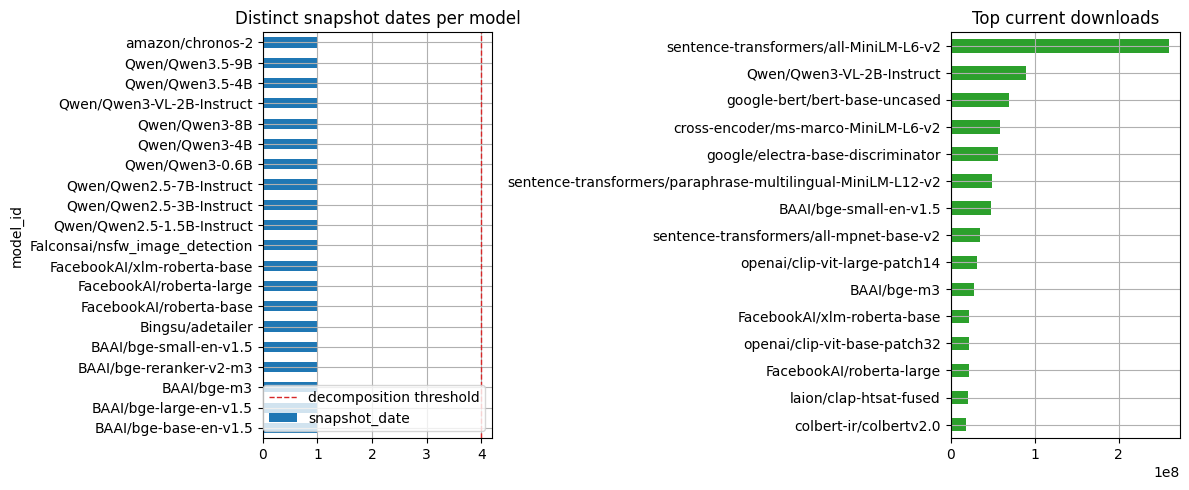

In [8]:
if not components.empty and "series" in summary.columns:
    top_models = summary["series"].head(4).tolist()
    fig, axes = plt.subplots(len(top_models), 2, figsize=(11, max(3.0, 2.4 * len(top_models))), squeeze=False)
    for row, model_id in enumerate(top_models):
        panel = components.loc[components["series"].eq(model_id)].sort_values("date").copy()
        panel["date"] = pd.to_datetime(panel["date"])
        axes[row, 0].plot(panel["date"], panel["observed"], label="observed", linewidth=1.6)
        axes[row, 0].plot(panel["date"], panel["trend"], label="trend", linewidth=1.8)
        axes[row, 0].set_title(model_id)
        axes[row, 1].bar(panel["date"], panel["residual"], color=np.where(panel["residual"] >= 0, "tab:red", "tab:blue"))
        axes[row, 1].set_title("residual")
    axes[0, 0].legend(loc="best")
else:
    snapshot_depth = series_log.groupby("model_id")["snapshot_date"].nunique().sort_values(ascending=False).head(20)
    top_downloads = snapshot_rank.dropna(subset=["downloads"]).head(15).sort_values("downloads")
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    snapshot_depth.sort_values().plot(kind="barh", ax=axes[0], color="tab:blue", title="Distinct snapshot dates per model")
    axes[0].axvline(4, color="tab:red", linestyle="--", linewidth=1.0, label="decomposition threshold")
    axes[0].legend(loc="lower right")
    top_downloads.plot(kind="barh", x="model_id", y="downloads", ax=axes[1], color="tab:green", legend=False, title="Top current downloads")
    axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


## 7. Guardrails


In [9]:
guardrails = article_language_guardrails()
guardrails


,unsafe,safer
0,This trend predicts the next price move.,This trend summarizes the observed public seri...
1,This model is better because it has more downl...,Downloads are a public adoption proxy and shou...
2,This repo is winning because stars are rising.,"Star velocity measures developer attention, no..."
3,This pageview spike proves importance.,Pageviews measure public attention during the ...
4,This residual is a buy signal.,This residual marks an event-like deviation fr...


In [10]:
save_table(snapshot_audit, "03_hf_snapshot_audit")
save_table(snapshot_rank, "03_hf_snapshot_rank")
save_table(summary, "03_hf_decomposition_or_collection_status")
if not events.empty:
    save_table(events, "03_hf_residual_events")
save_table(guardrails, "03_hf_guardrails")


saved: examples/hot_trends/outputs/03_hf_snapshot_audit.csv
saved: examples/hot_trends/outputs/03_hf_snapshot_rank.csv
saved: examples/hot_trends/outputs/03_hf_decomposition_or_collection_status.csv
saved: examples/hot_trends/outputs/03_hf_guardrails.csv
